In [ ]:
%matplotlib inline

import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt

from xxm.core.gaussian.emissions import GaussianEmissions
from xxm.lds import init
from xxm.lds.core import GaussianInitialModel, LinearGaussianDynamicsModel, Model
from xxm.lds.inference import inference_exact
from xxm.lds.learning import fit_em_many
from xxm.stats.gaussian import Gaussian, LinearGaussian

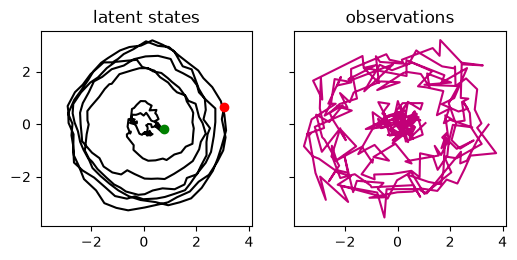

In [4]:
def make_rotating_lds(
    angle: float = 0.15,
    process_noise: float = 0.01,
    observation_noise: float = 0.1,
) -> Model:
    rotation = jnp.array(
        [
            [jnp.cos(angle), -jnp.sin(angle)],
            [jnp.sin(angle), jnp.cos(angle)],
        ]
    )

    return Model(
        initial=GaussianInitialModel(
            Gaussian(
                mean=jnp.array([1.0, 0.0]),
                covariance=0.01 * jnp.eye(2),
            )
        ),
        dynamics=LinearGaussianDynamicsModel(
            LinearGaussian(
                Affine(
                    coefficients=rotation,
                    bias=jnp.zeros(2),
                ),
                covariance=process_noise * jnp.eye(2),
            )
        ),
        emissions=GaussianEmissions(
            LinearGaussian(
                Affine(
                    coefficients=jnp.array(
                        [
                            [1.0, 0.5],
                            [-0.3, 0.8],
                        ]
                    ),
                    bias=jnp.zeros(2),
                ),
                covariance=observation_noise * jnp.eye(2),
            ),
        ),
    )


def plot_latent(ax, latents, color='k', **kwargs):
    ax.plot(latents[:, 0], latents[:, 1], color=color, **kwargs)
    ax.scatter(latents[0, 0], latents[0, 1], color='g', zorder=10)
    ax.scatter(latents[-1, 0], latents[-1, 1], color='r', zorder=10)
    ax.set(title='latent states', aspect='equal')


true_model = make_rotating_lds()

latents_true, observations = true_model.sample(
    num_time_steps=300,
    key=jax.random.key(0),
)


def plot_data(latents, observations):

    f, axs = plt.subplots(ncols=2, figsize=(6, 4), sharex=True, sharey=True)

    ax = axs[0]
    plot_latent(ax, latents)
    ax.set(title='latent states', aspect='equal')

    ax = axs[1]
    ax.plot(observations[:, 0], observations[:, 1], color='xkcd:magenta')
    ax.set(title='observations', aspect='equal')


plot_data(latents_true, observations)

In [5]:
posterior = inference_exact(true_model, observations)

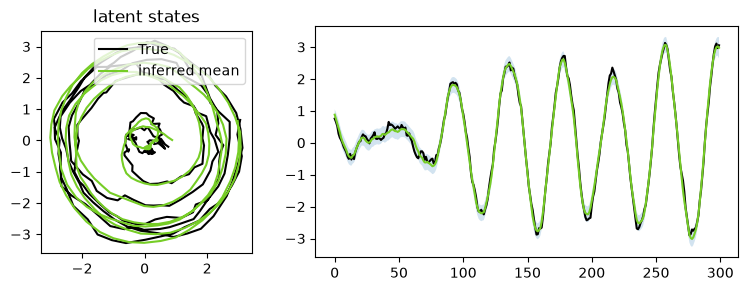

In [6]:
def plot_inference(states, posterior):
    f, axs = plt.subplots(ncols=2, gridspec_kw={'width_ratios': [1, 2]}, figsize=(9, 3))

    ax = axs[0]
    ax.plot(states[:, 0], states[:, 1], label='True', color='k')
    ax.plot(
        posterior.means[:, 0],
        posterior.means[:, 1],
        label='inferred mean',
        color='xkcd:apple green',
    )

    ax.set(
        title='latent states',
        aspect='equal',
    )

    ax.legend(loc='upper right')

    ax = axs[1]

    std = jnp.sqrt(posterior.covariances[:, 0, 0])

    ax.plot(states[:, 0], label='true', color='k')
    ax.plot(posterior.means[:, 0], label='posterior', color='xkcd:apple green')
    ax.fill_between(
        jnp.arange(len(states)),
        posterior.means[:, 0] - 2 * std,
        posterior.means[:, 0] + 2 * std,
        alpha=0.2,
    )


plot_inference(latents_true, posterior)

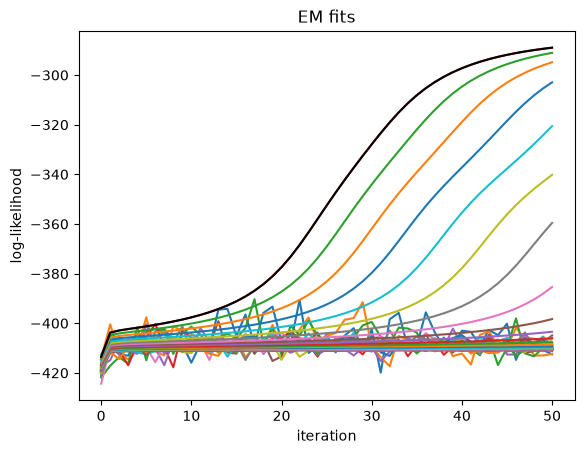

In [7]:
def plot_fits(fits, highlight_idx):
    f, ax = plt.subplots()

    ax.plot(fits.objective_traces.T)

    _, log_likelihoods = fits.get(highlight_idx)

    ax.plot(log_likelihoods, color='k')

    ax.set(
        xlabel='iteration',
        ylabel='log-likelihood',
        title='EM fits',
    )


initial_models = init.init_pca_gaussian_many(
    observations, state_dim=2, covariance_floors=jnp.logspace(-5, -2, 64)
)


fits = fit_em_many(
    initial_models,
    observations,
    num_iters=50,
)


best_idx = fits.best_index()
initial_model = initial_models[best_idx]
fitted_model = fits.get(best_idx)[0]

plot_fits(fits, highlight_idx=best_idx)

In [8]:
initial_posterior = inference_exact(initial_model, observations)
fitted_posterior = inference_exact(fitted_model, observations)

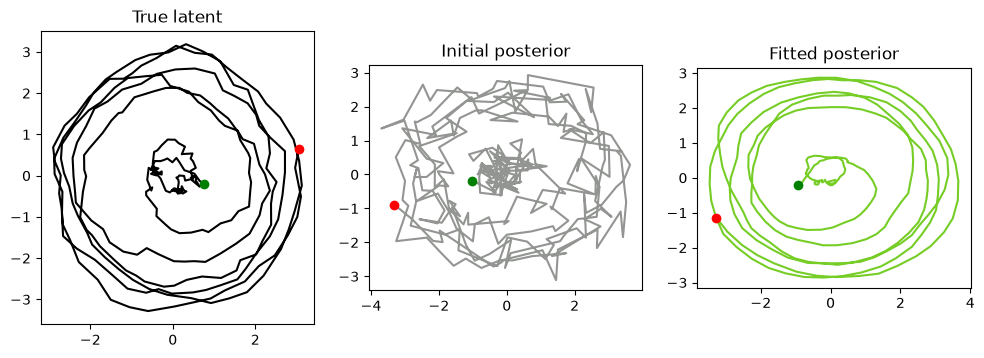

In [9]:
def plot_latent_comparison(latents_true, initial_posterior, fitted_posterior):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    ax = axes[0]
    plot_latent(ax, latents_true)
    ax.set(
        title='True latent',
        aspect='equal',
    )

    ax = axes[1]
    plot_latent(ax, initial_posterior.means, color='xkcd:grey')
    ax.set(
        title='Initial posterior',
        aspect='equal',
    )

    ax = axes[2]
    plot_latent(ax, fitted_posterior.means, color='xkcd:apple green')
    ax.set(
        title='Fitted posterior',
        aspect='equal',
    )


plot_latent_comparison(latents_true, initial_posterior, fitted_posterior)

In [14]:
initial_prediction = initial_model.emissions.model.conditional(initial_posterior.means).mean
fitted_prediction = fitted_model.emissions.model.conditional(fitted_posterior.means).mean

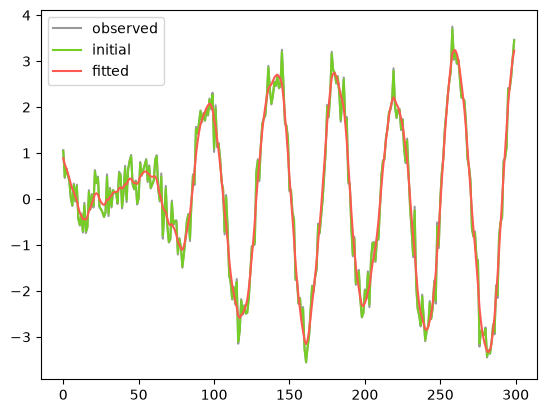

In [15]:
def plot_observations(observations, initial_prediction, fitted_prediction):
    f, ax = plt.subplots()

    ax.plot(observations[:, 0], alpha=0.4, label='observed', color='k')
    ax.plot(initial_prediction[:, 0], label='initial', color='xkcd:apple green')
    ax.plot(fitted_prediction[:, 0], label='fitted', color='xkcd:coral')
    ax.legend()


plot_observations(observations, initial_prediction, fitted_prediction)